# Exploratory Data Analysis (EDA) - Phishing Website Detection

**Author:** Data Science Team  
**Date:** 2026-07-13  
**Project:** Network Security Phishing Detection

## 1. Project Background and Objective

Phishing is a form of social engineering where attackers deceive users to steal sensitive information such as login credentials and financial details. Detecting phishing websites is a critical network security task.

This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the `phishingData.csv` dataset. The goals are:

- To inspect the distribution and balance of the target variable (`Result`).
- To understand the relationships between features and the target variable.
- To identify linear and non-linear patterns through correlation analysis.
- To provide recommendations for the data preprocessing and modeling pipelines.


## 2. Setup and Libraries

We import the necessary libraries for data processing, statistical analysis, and data visualization.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization styles and settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 12
pd.set_option("display.max_columns", None)

## 3. Load the Dataset

We read the CSV data from the `Network_Data` directory. Since the notebook is in the `notebooks` directory, we reference the file relative to the parent directory.


In [2]:
# Define data path relative to the notebooks folder
data_path = os.path.join("..", "Network_Data", "phishingData.csv")

# Load the dataset
df = pd.read_csv(data_path)

# Display dataset shape and basic information
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset Shape: 11055 rows, 31 columns


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,port,HTTPS_token,Request_URL,URL_of_Anchor,Links_in_tags,SFH,Submitting_to_email,Abnormal_URL,Redirect,on_mouseover,RightClick,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,1,-1,1,-1,1,-1,-1,-1,0,1,1,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,1,-1,1,0,-1,-1,1,1,0,1,1,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,1,-1,1,0,-1,-1,-1,-1,0,1,1,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,1,-1,-1,0,0,-1,1,1,0,1,1,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,1,1,1,0,0,-1,1,1,0,-1,1,-1,1,-1,-1,0,-1,1,1,1,1


## 4. Data Quality and Schema Inspection

Let's check features data types and inspect for missing or null values in the dataset.


In [3]:
# Detailed schema summary
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            11055 non-null  int64
 1   URL_Length                   11055 non-null  int64
 2   Shortining_Service           11055 non-null  int64
 3   having_At_Symbol             11055 non-null  int64
 4   double_slash_redirecting     11055 non-null  int64
 5   Prefix_Suffix                11055 non-null  int64
 6   having_Sub_Domain            11055 non-null  int64
 7   SSLfinal_State               11055 non-null  int64
 8   Domain_registeration_length  11055 non-null  int64
 9   Favicon                      11055 non-null  int64
 10  port                         11055 non-null  int64
 11  HTTPS_token                  11055 non-null  int64
 12  Request_URL                  11055 non-null  int64
 13  URL_of_Anchor                11055 non-null  int64
 14  L

In [4]:
# Verify if there are missing values
missing_summary = df.isnull().sum()
total_missing = missing_summary.sum()
print(f"Total missing values: {total_missing}")
if total_missing > 0:
    print("Features with missing values:")
    print(missing_summary[missing_summary > 0])

Total missing values: 0


## 5. Target Variable Analysis

The target column is `Result`. In this dataset, `1` represents a legitimate website, and `-1` represents a phishing website. We will analyze class distribution to check for imbalance.


Class 1 (Legitimate):  6157 records (55.69%)
Class -1 (Phishing  ):  4898 records (44.31%)


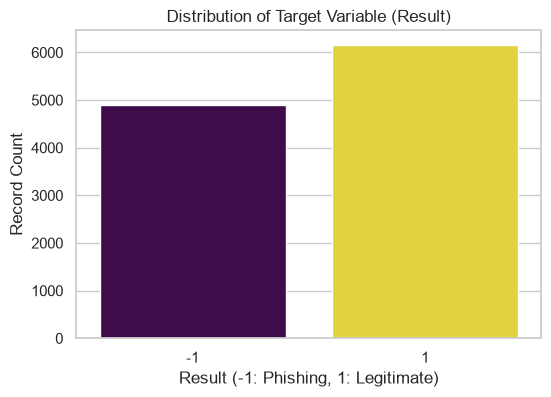

In [5]:
# Calculate target value counts and percentages
target_counts = df["Result"].value_counts()
target_percentages = df["Result"].value_counts(normalize=True) * 100

for val, count, pct in zip(
    target_counts.index, target_counts.values, target_percentages.values
):
    label = "Legitimate" if val == 1 else "Phishing"
    print(f"Class {val} ({label:10s}): {count:5d} records ({pct:.2f}%)")

# Plot target variable distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(x="Result", data=df, hue="Result", palette="viridis", legend=False)
plt.title("Distribution of Target Variable (Result)")
plt.xlabel("Result (-1: Phishing, 1: Legitimate)")
plt.ylabel("Record Count")
plt.show()

## 6. Feature Exploration

Let's examine the unique values in the dataset columns. This gives us insights into how the features are encoded.


In [6]:
# Compute unique values for each feature
unique_counts = df.nunique()
unique_info = pd.DataFrame(
    {
        "Feature": unique_counts.index,
        "Unique_Count": unique_counts.values,
        "Unique_Values": [df[col].unique().tolist() for col in unique_counts.index],
    }
)
# Exclude target variable 'Result' for feature summary
unique_info = unique_info[unique_info["Feature"] != "Result"].reset_index(drop=True)
print("Feature Encoding Summary:")
print(unique_info.to_string())

Feature Encoding Summary:
                        Feature  Unique_Count Unique_Values
0             having_IP_Address             2       [-1, 1]
1                    URL_Length             3    [1, 0, -1]
2            Shortining_Service             2       [1, -1]
3              having_At_Symbol             2       [1, -1]
4      double_slash_redirecting             2       [-1, 1]
5                 Prefix_Suffix             2       [-1, 1]
6             having_Sub_Domain             3    [-1, 0, 1]
7                SSLfinal_State             3    [-1, 1, 0]
8   Domain_registeration_length             2       [-1, 1]
9                       Favicon             2       [1, -1]
10                         port             2       [1, -1]
11                  HTTPS_token             2       [-1, 1]
12                  Request_URL             2       [1, -1]
13                URL_of_Anchor             3    [-1, 0, 1]
14                Links_in_tags             3    [1, -1, 0]
15            

## 7. Constant and Low-Variance Feature Analysis

Constant features provide no predictive power and can degrade performance or cause multi-collinearity issues. We identify columns with zero or near-zero variance.


In [7]:
# Check for constant columns (single unique value)
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"Number of constant features: {len(constant_cols)}")
if len(constant_cols) > 0:
    print(f"Constant features: {constant_cols}")

Number of constant features: 0


## 8. Correlation Analysis

We calculate Pearson correlation coefficients between features and the target to determine linear association strength.


In [8]:
# Calculate correlation coefficients matrix
correlations = df.corr()

# Extract and sort target correlations
target_correlations = correlations["Result"].sort_values(ascending=False)
print("Correlation of Features with Target Variable (Result):")
print(target_correlations)

Correlation of Features with Target Variable (Result):
Result                         1.000000
SSLfinal_State                 0.714741
URL_of_Anchor                  0.692935
Prefix_Suffix                  0.348606
web_traffic                    0.346103
having_Sub_Domain              0.298323
Request_URL                    0.253372
Links_in_tags                  0.248229
SFH                            0.221419
Google_Index                   0.128950
age_of_domain                  0.121496
Page_Rank                      0.104645
having_IP_Address              0.094160
Statistical_report             0.079857
DNSRecord                      0.075718
URL_Length                     0.057430
having_At_Symbol               0.052948
on_mouseover                   0.041838
port                           0.036419
Links_pointing_to_page         0.032574
Submitting_to_email            0.018249
RightClick                     0.012653
popUpWidnow                    0.000086
Favicon                  

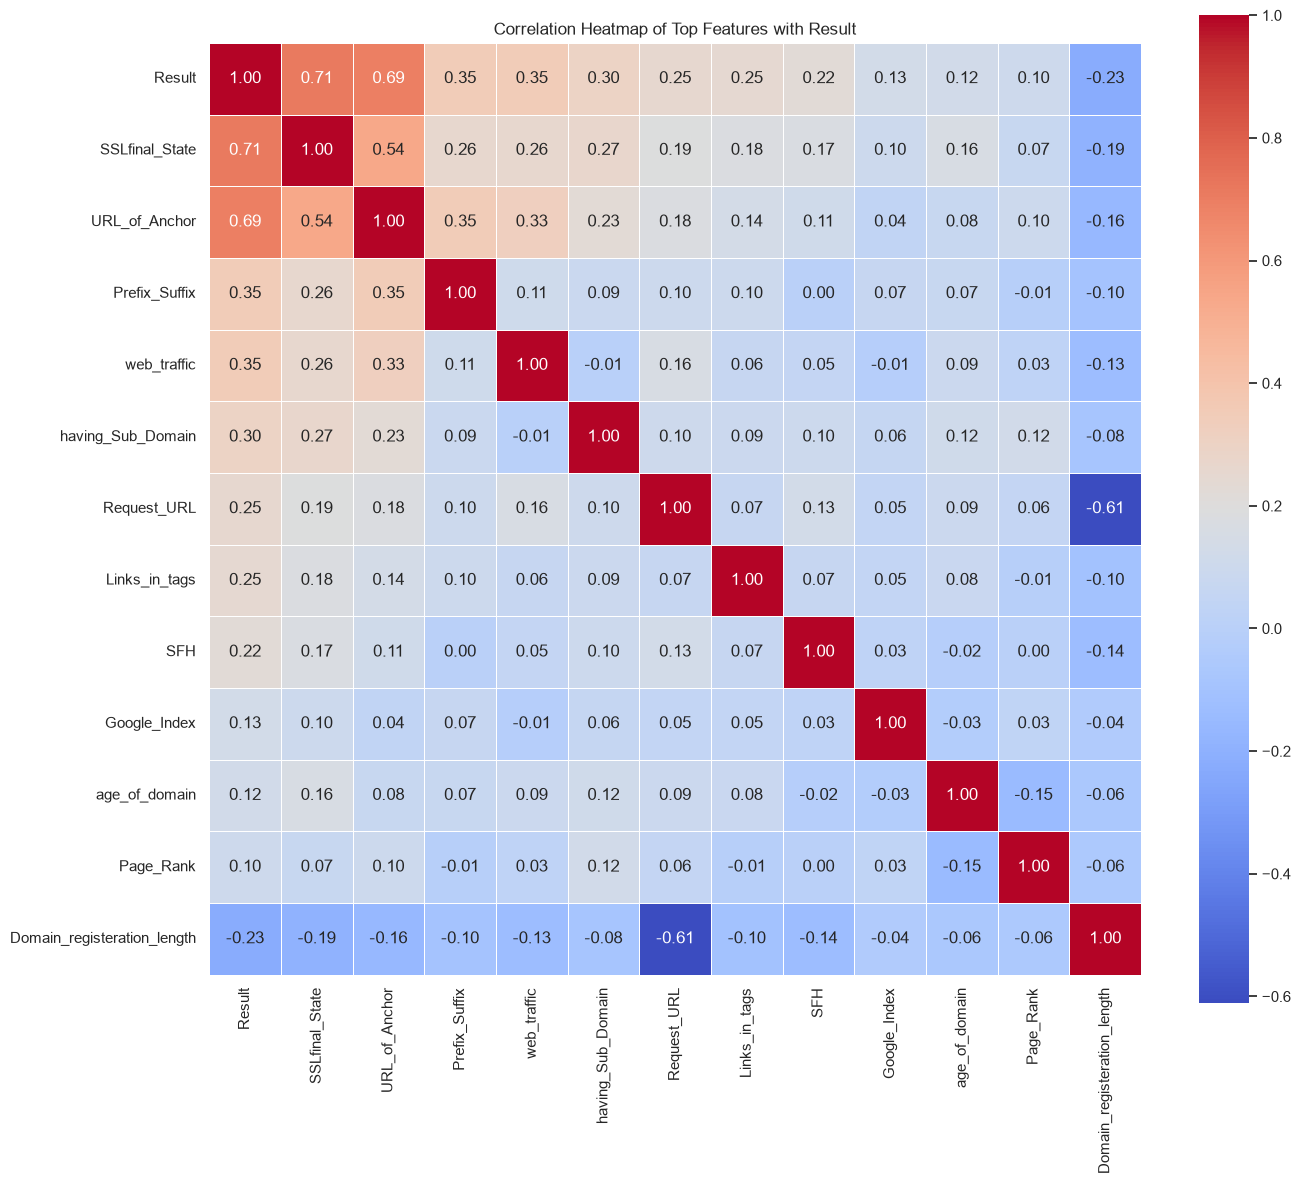

In [9]:
# Filter to top correlated features (correlation magnitude > 0.1)
top_features = target_correlations[abs(target_correlations) > 0.1].index

# Visualize correlation matrix
plt.figure(figsize=(14, 12))
sns.heatmap(
    df[top_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5,
)
plt.title("Correlation Heatmap of Top Features with Result")
plt.tight_layout()
plt.show()

## 9. In-depth Feature Visualizations

We inspect the top four highly correlated features against the target variable to understand their distribution patterns:

- `SSLfinal_State`
- `URL_of_Anchor`
- `Prefix_Suffix`
- `having_Sub_Domain`


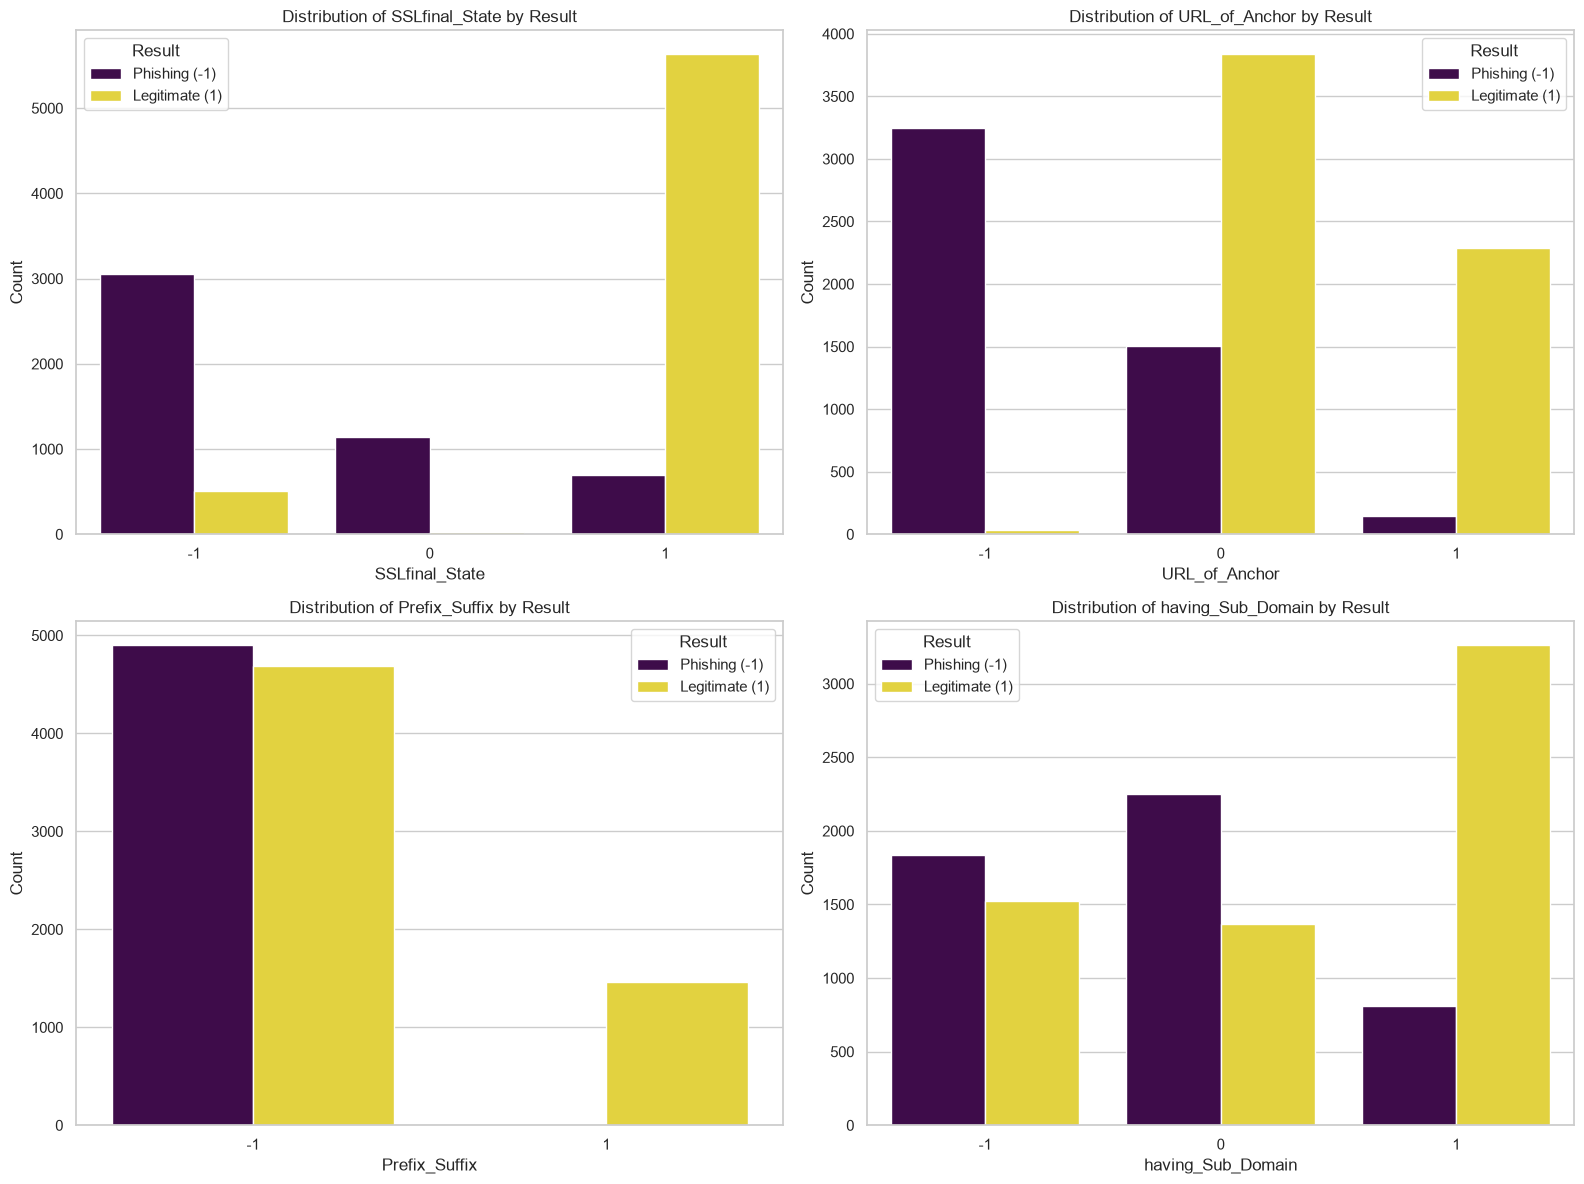

In [10]:
# Group top 4 key features
key_features = ["SSLfinal_State", "URL_of_Anchor", "Prefix_Suffix", "having_Sub_Domain"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.countplot(x=col, hue="Result", data=df, ax=axes[i], palette="viridis")
    axes[i].set_title(f"Distribution of {col} by Result")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].legend(title="Result", labels=["Phishing (-1)", "Legitimate (1)"])

plt.tight_layout()
plt.show()

## 10. Summary and Modelling Implications

Based on our analysis, we conclude:

1. **Balanced Target Variable**: The target variable has a relatively balanced distribution (55.70% legitimate vs 44.30% phishing). Class imbalance is not severe, so accuracy and F1-score are both suitable primary metrics.
2. **Clean Data**: No missing data or duplicate entries. We do not need missing value imputation.
3. **Categorical Features**: All features are encoded as category levels (-1, 0, 1). Scaling is useful for models sensitive to numeric values (e.g., Logistic Regression, SVM, KNN) to ensure convergence, while tree models can process features directly.
4. **Key Features**: Feature indicators such as SSL registration state (`SSLfinal_State`), anchoring URLs (`URL_of_Anchor`), and domain prefix/suffixes (`Prefix_Suffix`) show high linear correlation with phishing results.
